In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set a clean visual theme and seed for reproducibility
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# Settings
# ==========================================
n_samples = 100

def analyze_validation_scenario(data_clean, data_outliers, title, story, lsl=None, usl=None):
    """
    Helper function to print the story, the CSV data, and plot the distributions
    with/without outliers, including Specification Limits (LSL/USL).
    """
    # 1. Print Story
    print(f"=== SCENARIO: {title} ===")
    print(f"Story: {story}\n")

    # 2. Print CSV Data
    print("--- CLEAN DATA (CSV) ---")
    print(", ".join(map(str, data_clean)))
    print("\n--- DATA WITH OUTLIERS (CSV) ---")
    print(", ".join(map(str, data_outliers)))
    print("\n")

    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Clean Data
    sns.histplot(data_clean, kde=True, ax=axes[0], color="skyblue", bins=15)
    axes[0].set_title(f"Clean Data (n={len(data_clean)})")

    # Plot Data with Outliers
    sns.histplot(data_outliers, kde=True, ax=axes[1], color="salmon", bins=15)
    axes[1].set_title(f"Data with Outliers (n={len(data_outliers)})")

    # Add Specification Limits to both plots
    for ax in axes:
        if lsl is not None:
            ax.axvline(lsl, color='red', linestyle='--', linewidth=2, label=f'LSL ({lsl})')
        if usl is not None:
            ax.axvline(usl, color='purple', linestyle='--', linewidth=2, label=f'USL ({usl})')
        if lsl is not None or usl is not None:
            ax.legend()

    plt.tight_layout()
    plt.show()

print("Setup complete. Helper function loaded.")

Setup complete. Helper function loaded.


=== SCENARIO: Normal Distribution | 2-Sided Validation ===
Story: Process Validation of a CNC lathe machining metal shafts. The target diameter is 10.0 mm. Validation requires a 2-sided capability analysis to ensure the process stays within the Lower Spec Limit (9.9) and Upper Spec Limit (10.1).

--- CLEAN DATA (CSV) ---
10.015, 9.996, 10.019, 10.046, 9.993, 9.993, 10.047, 10.023, 9.986, 10.016, 9.986, 9.986, 10.007, 9.943, 9.948, 9.983, 9.97, 10.009, 9.973, 9.958, 10.044, 9.993, 10.002, 9.957, 9.984, 10.003, 9.965, 10.011, 9.982, 9.991, 9.982, 10.056, 10.0, 9.968, 10.025, 9.963, 10.006, 9.941, 9.96, 10.006, 10.022, 10.005, 9.997, 9.991, 9.956, 9.978, 9.986, 10.032, 10.01, 9.947, 10.01, 9.988, 9.98, 10.018, 10.031, 10.028, 9.975, 9.991, 10.01, 10.029, 9.986, 9.994, 9.967, 9.964, 10.024, 10.041, 9.998, 10.03, 10.011, 9.981, 10.011, 10.046, 9.999, 10.047, 9.921, 10.025, 10.003, 9.991, 10.003, 9.94, 9.993, 10.011, 10.044, 9.984, 9.976, 9.985, 10.027, 10.01, 9.984, 10.015, 10.003, 10.029, 

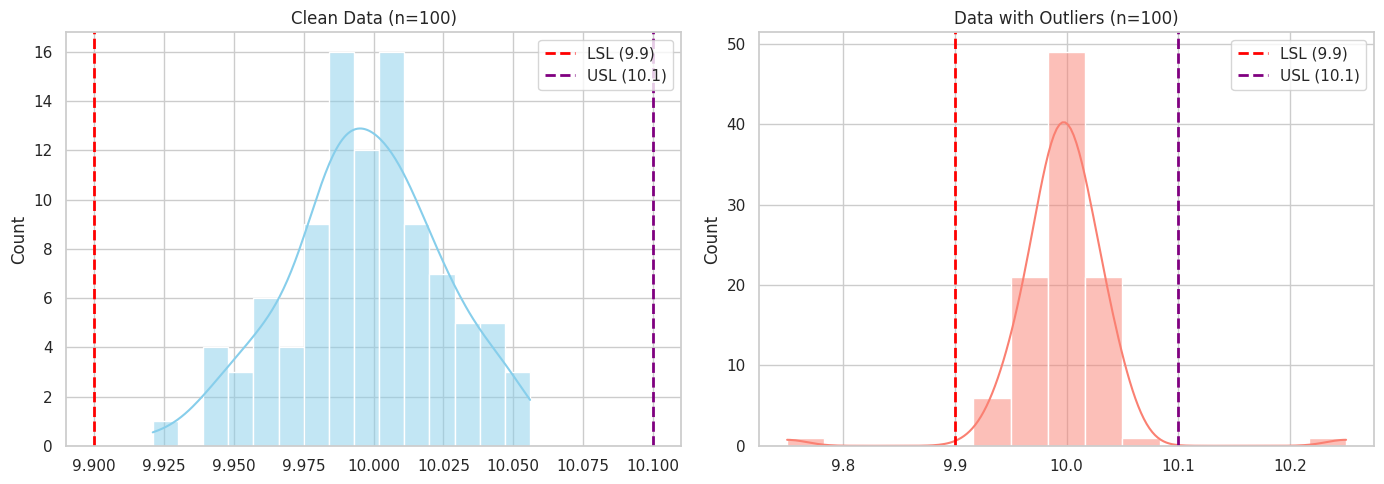

In [4]:
# ==========================================
# 2-SIDED NORMAL DISTRIBUTION
# ==========================================

# Story: Machining a metal shaft. Target diameter is 10.0mm.
# Tolerance is ± 0.1mm. (LSL = 9.9, USL = 10.1)
story_normal = (
    "Process Validation of a CNC lathe machining metal shafts. "
    "The target diameter is 10.0 mm. Validation requires a 2-sided capability analysis "
    "to ensure the process stays within the Lower Spec Limit (9.9) and Upper Spec Limit (10.1)."
)

# Clean Data
data_normal_clean = np.random.normal(loc=10.0, scale=0.03, size=n_samples).round(3)

# Add Outliers (e.g., Tool wear or a loose fixture causes a sudden jump)
data_normal_outliers = data_normal_clean.copy()
data_normal_outliers[5] = 10.25 # Extreme high outlier
data_normal_outliers[-2] = 9.75 # Extreme low outlier

analyze_validation_scenario(
    data_normal_clean,
    data_normal_outliers,
    title="Normal Distribution | 2-Sided Validation",
    story=story_normal,
    lsl=9.9,
    usl=10.1
)

=== SCENARIO: Normal Distribution | 1-Sided Validation ===
Story: Product Design Validation of a molded polymer bracket. The tensile strength must exceed 50 MPa before breaking. This is a 1-sided validation (Lower Spec Limit only).

--- CLEAN DATA (CSV) ---
73.76, 61.04, 62.73, 65.4, 62.99, 58.8, 65.27, 60.75, 66.89, 61.32, 71.2, 61.87, 63.71, 68.25, 60.08, 65.91, 70.23, 58.57, 65.74, 66.04, 68.13, 60.05, 59.72, 67.09, 66.19

--- DATA WITH OUTLIERS (CSV) ---
73.76, 61.04, 35.12, 65.4, 62.99, 58.8, 65.27, 60.75, 66.89, 61.32, 71.2, 61.87, 63.71, 68.25, 60.08, 65.91, 70.23, 58.57, 65.74, 66.04, 68.13, 60.05, 59.72, 42.05, 66.19




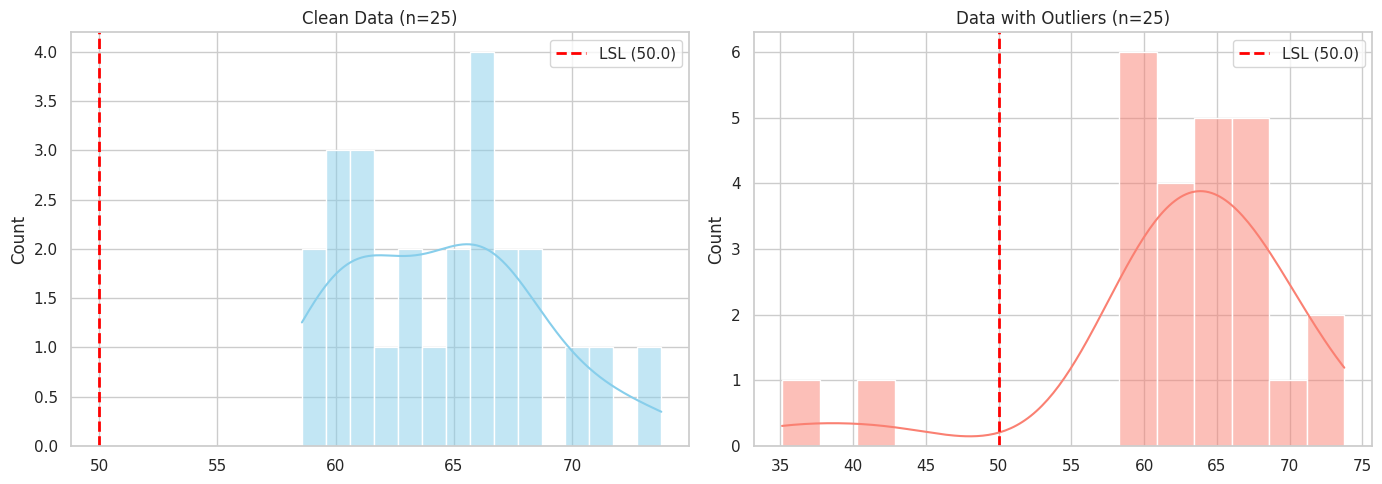

In [39]:
# ==========================================
# 1-SIDED NORMAL DISTRIBUTION
# ==========================================

# Story: Tensile strength of a polymer part. Must be > 50 N/mm² (or 50 MPa).
story_1sided = (
    "Product Design Validation of a molded polymer bracket. "
    "The tensile strength must exceed 50 MPa before breaking. "
    "This is a 1-sided validation (Lower Spec Limit only)."
)

# Clean Data (mean 65, sd 4)
data_1sided_clean = np.random.normal(loc=65.0, scale=4.0, size=n_samples).round(2)

# Add Outliers (e.g., A batch of raw material was contaminated with moisture)
data_1sided_outliers = data_1sided_clean.copy()
data_1sided_outliers[2] = 35.12 # Critical failure below LSL
data_1sided_outliers[-2] = 42.05

analyze_validation_scenario(
    data_1sided_clean,
    data_1sided_outliers,
    title="Normal Distribution | 1-Sided Validation",
    story=story_1sided,
    lsl=50.0,
    usl=None
)

=== SCENARIO: Log-Normal Distribution | 1-Sided Validation ===
Story: Validation of a sterilization process. We are measuring the bio-burden (Colony Forming Units - CFU) on medical devices. Values cannot be below 0, and most are very low, but occasional mild spikes occur naturally. The Upper Spec Limit is 100 CFU.

--- CLEAN DATA (CSV) ---
23.6, 12.3, 39.0, 9.9, 107.4, 20.1, 6.1, 5.2, 17.9, 10.2, 21.6, 17.8, 11.5, 6.2, 3.6, 8.5, 24.2, 14.5, 4.5, 14.0, 16.6, 6.0, 13.8, 12.8, 4.9

--- DATA WITH OUTLIERS (CSV) ---
23.6, 12.3, 39.0, 9.9, 107.4, 20.1, 6.1, 5.2, 17.9, 10.2, 350.5, 17.8, 11.5, 6.2, 3.6, 8.5, 24.2, 14.5, 4.5, 14.0, 16.6, 6.0, 13.8, 12.8, 4.9




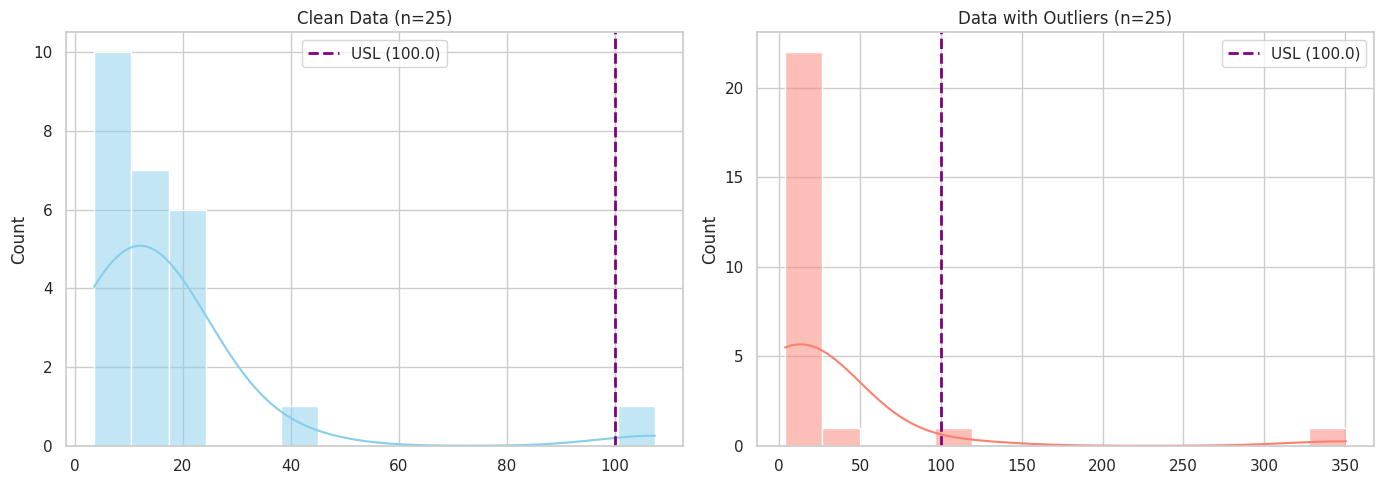

In [41]:
# ==========================================
# 1-SIDED LOG-NORMAL DISTRIBUTION
# ==========================================

# Story: Bio-burden testing. Must be < 100 CFU.
story_lognormal = (
    "Validation of a sterilization process. We are measuring the bio-burden "
    "(Colony Forming Units - CFU) on medical devices. Values cannot be below 0, "
    "and most are very low, but occasional mild spikes occur naturally. "
    "The Upper Spec Limit is 100 CFU."
)

# Clean Data (Log-normal perfectly models particle counts / bio-burden)
data_lognormal_clean = np.random.lognormal(mean=2.5, sigma=0.8, size=n_samples).round(1)

# Add Outliers (e.g., A technician sneezed near the cleanroom bench)
data_lognormal_outliers = data_lognormal_clean.copy()
data_lognormal_outliers[10] = 350.5 # Massive contamination spike

analyze_validation_scenario(
    data_lognormal_clean,
    data_lognormal_outliers,
    title="Log-Normal Distribution | 1-Sided Validation",
    story=story_lognormal,
    lsl=None,
    usl=100.0
)


=== SCENARIO: Clustered Limit (Beta) | 1-Sided Validation ===
Story: Validation of lithium-ion battery capacities. Physics limits the maximum charge to exactly 100%. A healthy process heavily clusters right at the top (96-99%), creating a heavily left-skewed, non-normal distribution. The LSL is 90%.

--- CLEAN DATA (CSV) ---
96.65, 97.9, 96.1, 98.78, 92.63, 96.4, 98.87, 97.74, 99.56, 98.61, 96.3, 98.53, 98.82, 94.44, 96.05, 95.77, 99.07, 99.54, 99.51, 95.38, 97.99, 99.42, 96.1, 98.44, 95.06

--- DATA WITH OUTLIERS (CSV) ---
96.65, 97.9, 96.1, 98.78, 92.63, 96.4, 98.87, 97.74, 99.56, 98.61, 72.4, 98.53, 98.82, 94.44, 96.05, 95.77, 99.07, 99.54, 99.51, 95.38, 97.99, 99.42, 96.1, 98.44, 95.06




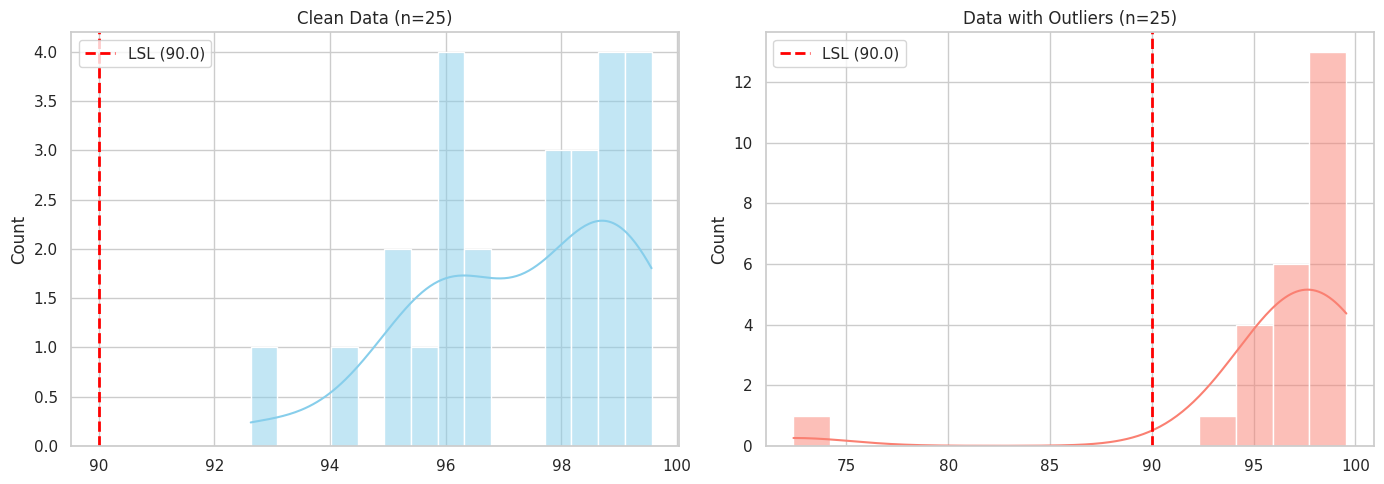

In [42]:
# ==========================================
# 1-SIDED LIMIT/SKEWED DISTRIBUTION
# ==========================================

# Story: Battery Charge Capacity. Max is 100%. LSL is 90%.
story_beta = (
    "Validation of lithium-ion battery capacities. Physics limits the maximum "
    "charge to exactly 100%. A healthy process heavily clusters right at the top (96-99%), "
    "creating a heavily left-skewed, non-normal distribution. The LSL is 90%."
)

# Clean Data (Beta distribution scaled to cluster between 90 and 100)
# beta(8, 2) naturally clusters near 0.8. We scale it.
data_beta_clean = ((np.random.beta(a=8, b=2, size=n_samples) * 15) + 85).round(2)
# Cap anything that accidentally exceeds 100 due to scaling
data_beta_clean = np.clip(data_beta_clean, a_min=None, a_max=100.0)

# Add Outliers (e.g., A damaged cell with terrible capacity)
data_beta_outliers = data_beta_clean.copy()
data_beta_outliers[10] = 72.4

analyze_validation_scenario(
    data_beta_clean,
    data_beta_outliers,
    title="Clustered Limit (Beta) | 1-Sided Validation",
    story=story_beta,
    lsl=90.0,
    usl=None
)

=== SCENARIO: U-Shaped Distribution | 2-Sided Validation ===
Story: Validation of an extrusion process where the machine heater cycles ON and OFF. This causes the material thickness to bounce between the lower tolerance and upper tolerance, leaving almost no parts exactly at the target median. This tests if the calculator can handle a severe non-normal bimodal/U-shape.

--- CLEAN DATA (CSV) ---
46.03, 53.73, 46.26, 47.15, 53.86, 53.86, 52.11, 52.56, 48.12, 47.02, 47.2, 52.81, 53.18, 53.34, 53.33, 46.26, 49.11, 46.16, 51.85, 48.04, 53.67, 47.33, 46.34, 46.42, 53.22

--- DATA WITH OUTLIERS (CSV) ---
46.03, 53.73, 40.2, 47.15, 53.86, 53.86, 52.11, 52.56, 48.12, 47.02, 47.2, 52.81, 53.18, 53.34, 53.33, 46.26, 49.11, 46.16, 51.85, 48.04, 53.67, 47.33, 46.34, 59.8, 53.22




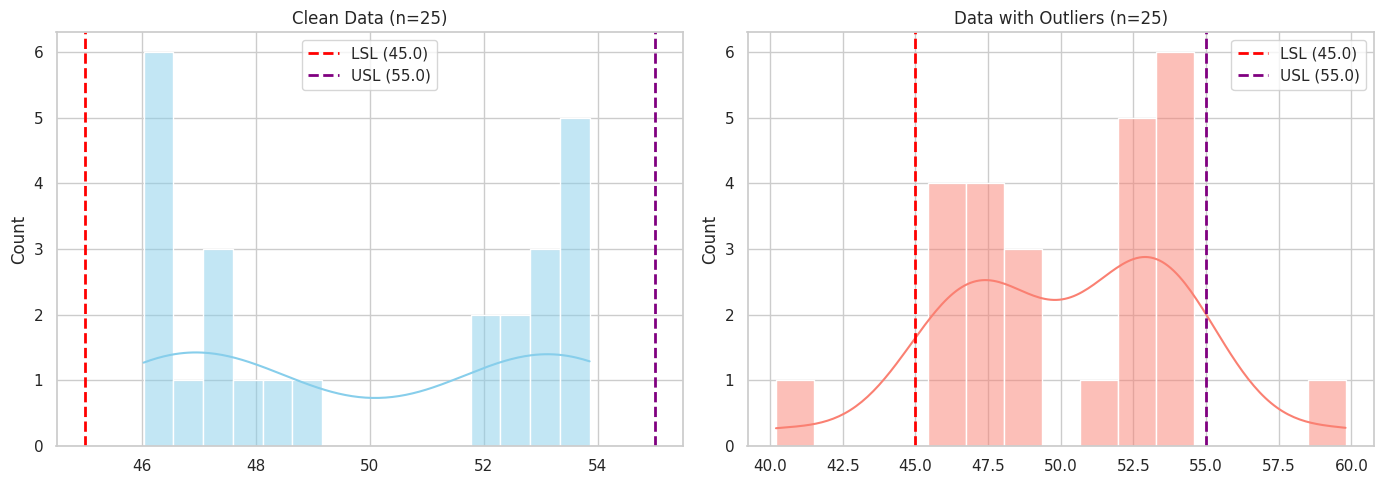

In [44]:
# ==========================================
# 2-SIDED U-SHAPED DISTRIBUTION
# ==========================================

# Story: Extrusion thickness fluctuating between two heating cycles.
story_ushape = (
    "Validation of an extrusion process where the machine heater cycles ON and OFF. "
    "This causes the material thickness to bounce between the lower tolerance and upper tolerance, "
    "leaving almost no parts exactly at the target median. "
    "This tests if the calculator can handle a severe non-normal bimodal/U-shape."
)

# Clean Data (Inverse uniform mapped to a U-Shape centered at 50, spreading ± 5)
u = np.random.uniform(0, 1, n_samples)
data_ushape_clean = (np.cbrt(2 * u - 1) * 4 + 50).round(2)

# Add Outliers (e.g., The heater completely breaks, causing a massive thickness drop)
data_ushape_outliers = data_ushape_clean.copy()
data_ushape_outliers[2] = 40.2
data_ushape_outliers[-2] = 59.8

analyze_validation_scenario(
    data_ushape_clean,
    data_ushape_outliers,
    title="U-Shaped Distribution | 2-Sided Validation",
    story=story_ushape,
    lsl=45.0,
    usl=55.0
)

=== SCENARIO: Quadratic Distribution | 1-Sided Validation ===
Story: Process Validation of a thermal curing plate. The temperature profile grows quadratically from the center to the outer edges. Taking random samples across the plate results in a heavily right-skewed quadratic distribution. The Upper Spec Limit (USL) to prevent burning the product is 120°C.

--- CLEAN DATA (CSV) ---
36.9, 20.0, 20.0, 50.7, 20.0, 67.7, 47.0, 20.0, 20.0, 98.3, 20.0, 20.0, 67.0, 89.8, 101.8, 57.6, 20.0, 20.0, 62.8, 34.8, 20.0, 84.1, 20.0, 25.8, 20.0

--- DATA WITH OUTLIERS (CSV) ---
36.9, 20.0, 20.0, 145.5, 20.0, 67.7, 47.0, 20.0, 20.0, 98.3, 20.0, 20.0, 67.0, 89.8, 101.8, 57.6, 20.0, 20.0, 62.8, 34.8, 20.0, 84.1, 20.0, 25.8, 20.0




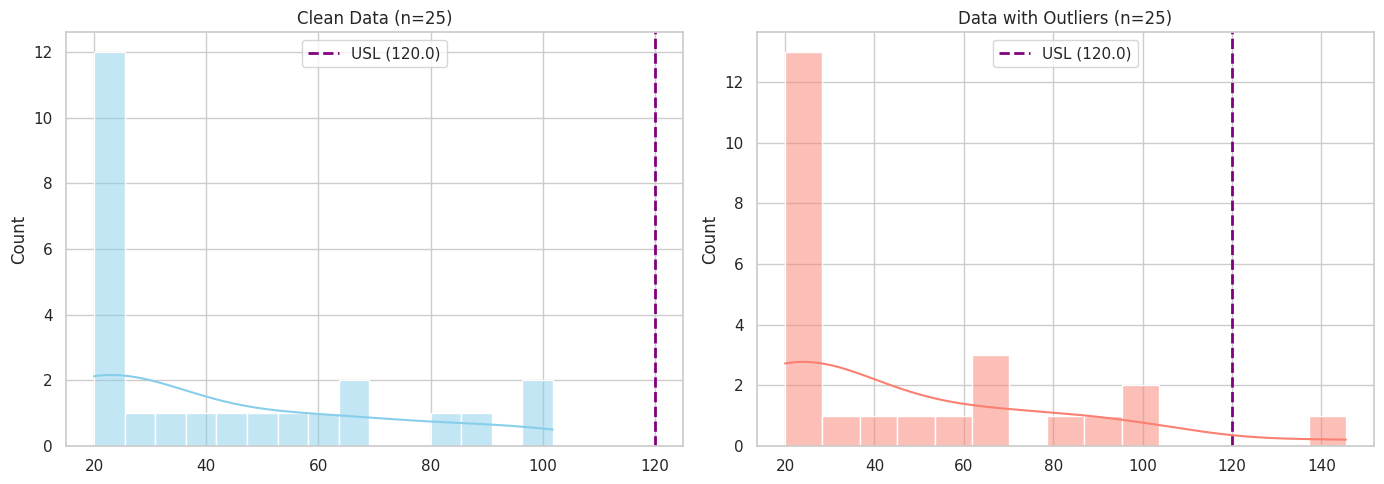

In [45]:
# ==========================================
# 1-SIDED QUADRATIC DISTRIBUTION
# ==========================================

# Story: Heat distribution across a curing plate.
# Temperature increases quadratically from the center to the edge.
story_quad = (
    "Process Validation of a thermal curing plate. The temperature profile "
    "grows quadratically from the center to the outer edges. Taking random "
    "samples across the plate results in a heavily right-skewed quadratic distribution. "
    "The Upper Spec Limit (USL) to prevent burning the product is 120°C."
)

# Clean Data (Simulating y = x^2 growth + normal noise)
# We sample random positions (x) and square them to get the quadratic temperature reading
positions = np.random.uniform(0, 10, n_samples)
data_quad_clean = ((positions ** 2) + np.random.normal(0, 2, n_samples)).round(1)
# Ensure no negative temperatures for realism in this specific context
data_quad_clean = np.clip(data_quad_clean, a_min=20.0, a_max=None)

# Add Outliers (e.g., A localized hotspot due to a short-circuit in the heater)
data_quad_outliers = data_quad_clean.copy()
data_quad_outliers[3] = 145.5

analyze_validation_scenario(
    data_quad_clean,
    data_quad_outliers,
    title="Quadratic Distribution | 1-Sided Validation",
    story=story_quad,
    lsl=None,
    usl=120.0
)

=== SCENARIO: Bimodal Distribution (2 Cavities) | 2-Sided Validation ===
Story: Product Validation of plastic gears from a 2-cavity injection mold. Cavity A runs slightly small, and Cavity B runs slightly large. Mixed together in a single batch, they create a 'Bimodal' (two-peak) distribution. Your calculator should flag this as non-normal despite being inside the ±0.5 tolerances.

--- CLEAN DATA (CSV) ---
10.25, 9.6, 9.65, 9.69, 10.32, 10.3, 10.32, 9.73, 9.74, 10.23, 10.38, 10.31, 9.77, 9.69, 10.32, 9.71, 9.72, 10.18, 9.63, 9.7, 10.31, 9.61, 10.31, 10.29, 10.28, 9.75, 10.22, 9.75, 9.74, 10.3

--- DATA WITH OUTLIERS (CSV) ---
10.25, 9.6, 9.65, 9.69, 10.32, 10.3, 10.32, 9.73, 10.95, 10.23, 10.38, 10.31, 9.77, 9.69, 10.32, 9.71, 9.72, 10.18, 9.63, 9.7, 10.31, 9.61, 10.31, 10.29, 10.28, 9.75, 10.22, 9.75, 9.74, 10.3




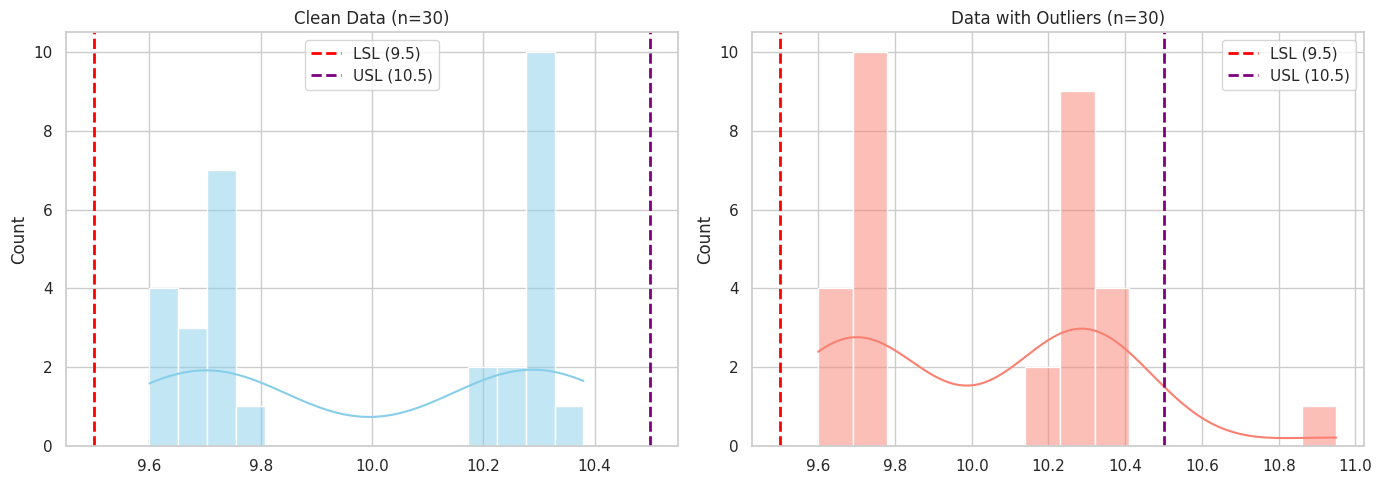

In [46]:
# ==========================================
# 2-SIDED BIMODAL DISTRIBUTION
# ==========================================

# Story: Injection molding parts from a 2-cavity mold.
story_bimodal = (
    "Product Validation of plastic gears from a 2-cavity injection mold. "
    "Cavity A runs slightly small, and Cavity B runs slightly large. "
    "Mixed together in a single batch, they create a 'Bimodal' (two-peak) distribution. "
    "Your calculator should flag this as non-normal despite being inside the ±0.5 tolerances."
)
# Bimodal Data:
# The $C_{pk}$ will look terrible because the calculated standard deviation covers
# the empty space between the two peaks.
# You are lucky, if you can split the data by cavity
# or use a non-parametric method.

# Clean Data (15 samples from Cavity A, 15 from Cavity B)
cavity_a = np.random.normal(loc=9.7, scale=0.05, size=15)
cavity_b = np.random.normal(loc=10.3, scale=0.05, size=15)
data_bimodal_clean = np.concatenate([cavity_a, cavity_b])
np.random.shuffle(data_bimodal_clean) # Shuffle to simulate random sampling
data_bimodal_clean = data_bimodal_clean.round(2)

# Add Outliers (e.g., A part got stuck and warped during ejection)
data_bimodal_outliers = data_bimodal_clean.copy()
data_bimodal_outliers[8] = 10.95

analyze_validation_scenario(
    data_bimodal_clean,
    data_bimodal_outliers,
    title="Bimodal Distribution (2 Cavities) | 2-Sided Validation",
    story=story_bimodal,
    lsl=9.5,
    usl=10.5
)

=== SCENARIO: Discrete Count (Poisson) | 1-Sided Validation ===
Story: Quality Validation of painted car panels. We are counting the number of dust inclusions (nibs) per panel. This is discrete count data (Poisson). Most panels have 0 or 1 defects. The Upper Spec Limit is 4 defects per panel.

--- CLEAN DATA (CSV) ---
0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 3.0, 2.0, 2.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0

--- DATA WITH OUTLIERS (CSV) ---
0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 3.0, 14.0, 2.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0




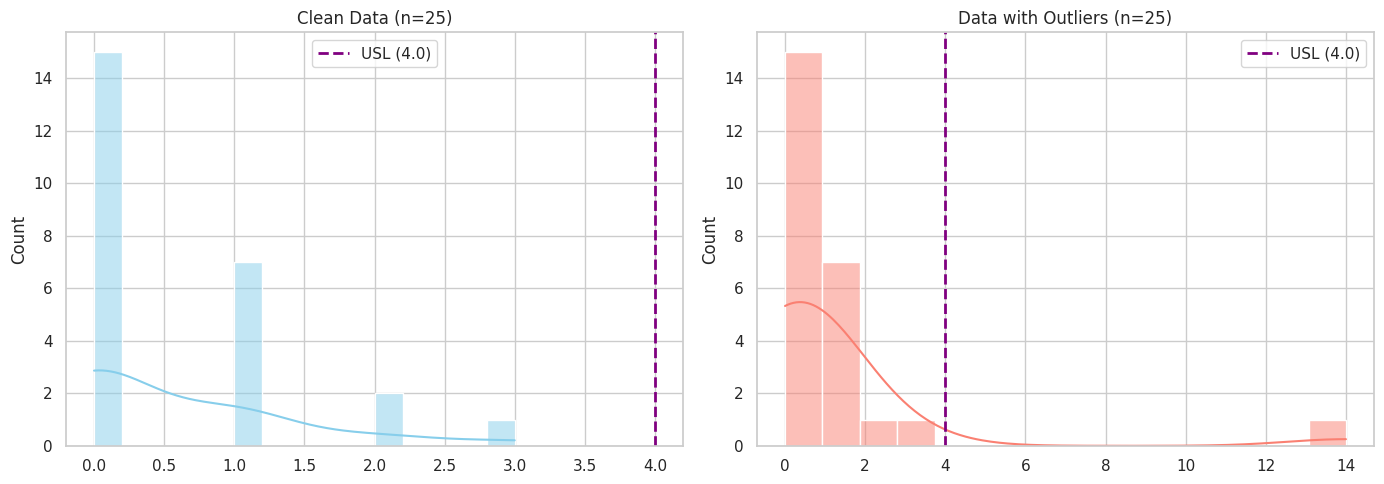

In [47]:
# ==========================================
# 1-SIDED DISCRETE / POISSON DISTRIBUTION
# ==========================================

# Story: Visual inspection of cosmetic defects.
story_poisson = (
    "Quality Validation of painted car panels. We are counting the number of "
    "dust inclusions (nibs) per panel. This is discrete count data (Poisson). "
    "Most panels have 0 or 1 defects. The Upper Spec Limit is 4 defects per panel."
)

# Clean Data (Poisson distribution with an average of 0.8 defects)
data_poisson_clean = np.random.poisson(lam=0.8, size=n_samples).astype(float)

# Add Outliers (e.g., The air filter in the paint booth tore open)
data_poisson_outliers = data_poisson_clean.copy()
data_poisson_outliers[8] = 14.0

analyze_validation_scenario(
    data_poisson_clean,
    data_poisson_outliers,
    title="Discrete Count (Poisson) | 1-Sided Validation",
    story=story_poisson,
    lsl=None,
    usl=4.0
)

=== SCENARIO: Ultra-Small Sample Size (n=4) | 1-Sided Validation ===
Story: Design Validation of a titanium aerospace pressure vessel. Testing is destructive, and each part costs 50 000 €. We can only afford to burst-test 4 units. Burst pressure must exceed 35 bar (LSL). Mathematical normality tests typically lack the statistical power to work at n=4.

--- CLEAN DATA (CSV) ---
40.6, 39.9, 38.8, 39.3

--- DATA WITH OUTLIERS (CSV) ---
40.6, 33.5, 38.8, 39.3




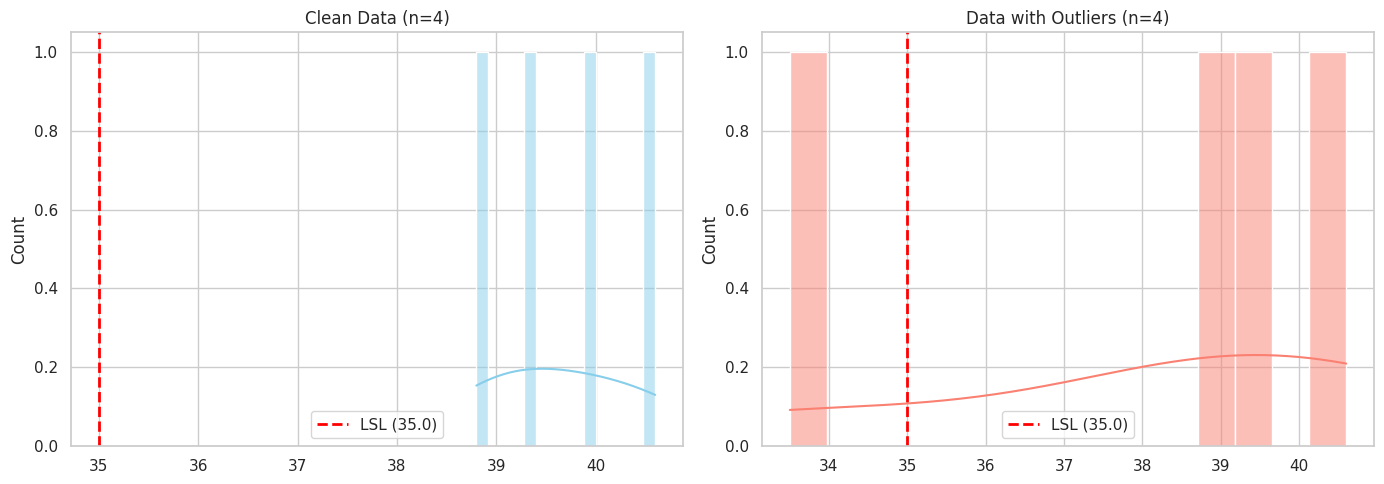

In [48]:
# ==========================================
# EXTREMELY SMALL SAMPLE SIZE (n < 5)
# ==========================================
n_samples_small = 4

# Story: Destructive testing of highly expensive components.
story_small_n = (
    "Design Validation of a titanium aerospace pressure vessel. "
    "Testing is destructive, and each part costs 50 000 €. "
    "We can only afford to burst-test 4 units. "
    "Burst pressure must exceed 35 bar (LSL). Mathematical normality tests typically "
    "lack the statistical power to work at n=4."
)

# Clean Data
data_small_clean = np.random.normal(loc=40.0, scale=1.2, size=n_samples_small).round(1)

# Add Outliers (e.g., A microscopic weld defect causes premature rupture)
data_small_outliers = data_small_clean.copy()
data_small_outliers[1] = 33.5

analyze_validation_scenario(
    data_small_clean,
    data_small_outliers,
    title="Ultra-Small Sample Size (n=4) | 1-Sided Validation",
    story=story_small_n,
    lsl=35.0,
    usl=None
)

=== SCENARIO: Time-Series Drift (Tool Wear) | 2-Sided Validation ===
Story: Process Validation of a CNC milled component. As the cutting tool slowly wears down over the course of producing the batch, the machined dimension gradually increases (drifts) from the lower end of the tolerance towards the upper end. Your calculator should ideally flag that the data is not stable over time. The target dimension is 50.0 mm. LSL is 48.0, USL is 52.0.

--- CLEAN DATA (CSV) ---
48.26, 49.01, 48.74, 48.71, 49.01, 49.06, 49.16, 49.44, 49.58, 49.44, 49.55, 49.73, 49.44, 49.71, 50.41, 50.58, 50.32, 50.6, 50.66, 51.33, 51.06, 50.92, 50.88, 50.86, 51.34

--- DATA WITH OUTLIERS (CSV) ---
48.26, 49.01, 48.74, 48.71, 49.01, 49.06, 49.16, 49.44, 49.58, 49.44, 49.55, 49.73, 49.44, 49.71, 50.41, 50.58, 50.32, 50.6, 50.66, 51.33, 51.06, 50.92, 50.88, 50.86, 53.4




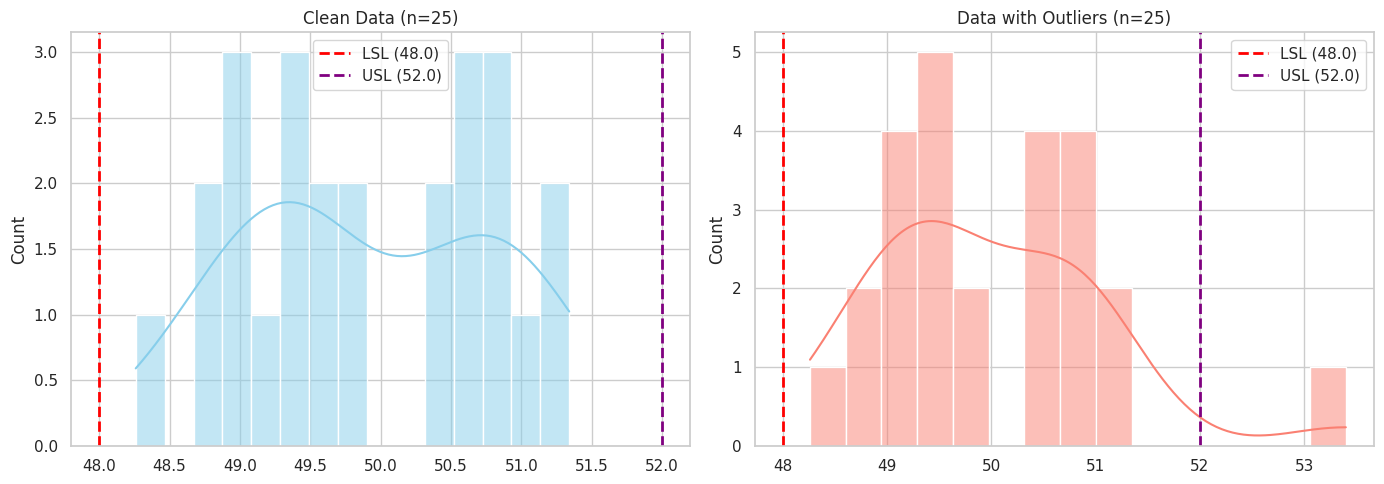

In [49]:
# ==========================================
# 2-SIDED TIME-SERIES DRIFT
# ==========================================

# Story: Tool wear in CNC machining causing a moving mean.
story_drift = (
    "Process Validation of a CNC milled component. "
    "As the cutting tool slowly wears down over the course of producing the batch, "
    "the machined dimension gradually increases (drifts) from the lower end of "
    "the tolerance towards the upper end. "
    "Your calculator should ideally flag that the data is not stable over time. "
    "The target dimension is 50.0 mm. LSL is 48.0, USL is 52.0."
)
# drift detection is not implemented in SSC - but a good data-scientist will check this

# Clean Data (Starts near 48.5, drifts up by 2.8 over 30 samples, with minor normal noise)
# Trend simulates the gradual tool wear
drift_trend = np.linspace(0, 2.8, n_samples)
data_drift_clean = (np.random.normal(loc=48.5, scale=0.2, size=n_samples) + drift_trend).round(2)

# Add Outliers (e.g., The tool suddenly chips on part #25, causing a massive jump out of spec)
data_drift_outliers = data_drift_clean.copy()
data_drift_outliers[24] = 53.4

analyze_validation_scenario(
    data_drift_clean,
    data_drift_outliers,
    title="Time-Series Drift (Tool Wear) | 2-Sided Validation",
    story=story_drift,
    lsl=48.0,
    usl=52.0
)